<a href="https://colab.research.google.com/github/GabCAD92/Machine-learning-tasks/blob/main/Regressions_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning
## Supervised Learning: Regressions

This lesson introduces __Linear__ and __Polynomial Regressions__ from scratch and using __SKLearn__.


### Professor:

<img src="https://www.sorocaba.unesp.br/Home/Graduacao/EngenhariadeControleeAutomacao/alexandre/alex_marta1_small.jpg" width="100" style="float: left; margin-right: 5px;" border="10px" />

  __Prof. Dr. Alexandre da Silva Simões__ <br>
  Department of Control and Automation Engineering (DECA) <br>
  Institute of Science and Technology of Sorocaba (ICTS) <br>
  São Paulo State University (Unesp) <br>
  www.sorocaba.unesp.br/professor/assimoes

<br/>

Based on notebooks related to the book:
* Géron, A. "Hands-On Machine Learning with Scikit-Learn and TensorFlow", O’Reilly Media Inc., Sebastopol, CA, EUA.

# Table of Contents


1. Understanding the problem... <br>
   1.1. RoboCup soccer context <br>
   1.2. Loading data <br>
   1.3. 3D Viewing <br>

2. Linear Regression (LR) <br>
   2.1. XY Regression <br>
   2.1.1 Hypothesis initialization <br>
      2.1.2. Cost function <br>
      2.1.3. Hypothesis update <br>
      2.1.4. Linear Regression function <br>
      2.1.5. The influence of the Learning Rate <br>
   2.2. XZ Regression <br>
   2.3. YZ Regression <br>
   2.4. Final trajectory <br>
   2.5. Linear Regression with SKLearn <br>
3. Polynomial Regression (PR) <br>
   3.1. Loading data <br>
   3.2. Creating a Polynomial Regression function <br>
   3.3. YZ Polynomial Regression <br>
   3.4. YX Polynomial Regression <br>
   3.5. XZ Polynomial Regression <br>
   3.6. Final trajectory <br>
4. Regularization (L1/L2) <br>
   4.1. Example of use <br>
<br>

____

## 1. Understanding the problem...

### 1.1. RoboCup soccer context

Consider that your are a goalkeeper in a robotic soccer match at __RoboCup Teen Size League__. Your opponent will kick a ball against you. <br>
This is your view:

<img src="https://drive.google.com/uc?id=1CE3q6ulFp5Z1GT3GGyH1FEXFu6bqQJbY" width="550" style="float: left; margin-right: 5px;" border="0px" />


Your __goal__ is to predict the position of the ball to intercept it, that is, to defend your goal! <br>
<br>

<img src="https://drive.google.com/uc?id=1IA76-4F9E7_EnsIi1XaI4Fxnm_XayxGc" width="350" style="float: left; margin-right: 5px;" border="0px" />

The dimensions of your field are:

<img src="https://drive.google.com/uc?id=1Xv2d6EbERxbMPqXQt8f1fj3LeiBobuSc" width="350" style="float: left; margin-right: 5px;" border="0px" />

Consider that:
* Your data is captured with a rate of 60 frames/second, and you have waited 1/3 of a second;
* The captured data refers to the center of the ball;
* The ball is a size 5 FIFA ball:

<img src="https://drive.google.com/uc?id=1uBwnf5XTadAySKW4K__o1ldUHGJkG01u" width="150" style="float: left; margin-right: 5px;" border="0px" />


In [14]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive/')
path = '/content/drive/My Drive/Colab Notebooks/kick1.dat'

with open(path, "rt") as f:
    kick1 = pd.read_csv(path, names=['X','Y','Z'], skiprows=1, sep=' ')

num_examples, num_dims = kick1.shape
x_values = kick1.iloc[:,0]
y_values = kick1.iloc[:,1]
z_values = kick1.iloc[:,2]
kick1

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,X,Y,Z
0,-0.305,1.999,0.103
1,-0.368,1.968,0.149
2,-0.370,1.902,0.110
3,-0.480,1.841,0.135
4,-0.532,1.807,0.111
5,-0.575,1.733,0.120
6,-0.583,1.690,0.111
7,-0.618,1.649,0.108
8,-0.702,1.611,0.117
9,-0.783,1.568,0.107


In [13]:
import os

file_path = '/content/drive/My Drive/Colab Notebooks/kick1.dat'
if os.path.exists(file_path):
    print(f"The file '{file_path}' exists.")
else:
    print(f"The file '{file_path}' does NOT exist.")

The file '/content/drive/My Drive/Colab Notebooks/kick1.dat' exists.


### 1.2. Loading data

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.3. 3D Viewing

Let's see the data in a 3D graph...

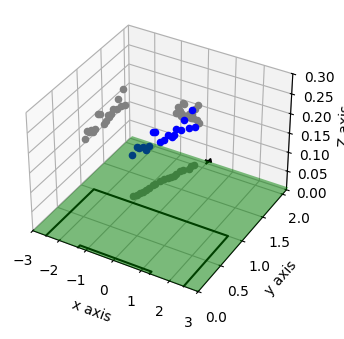

In [17]:
#3D view...
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np

def plot_data(X, xy=0, yx=0, xz=0, yz=0):
    XMAX = 3
    XMIN = -3
    YMAX = 2.15
    ZMAX = 0.3
    fig = plt.figure(figsize=plt.figaspect(0.4)*0.8)
    ax = plt.axes(projection='3d')
    x = [-XMAX,-XMAX,XMAX,XMAX]
    y = [0,YMAX,YMAX,0]
    z = [0,0,0,0]
    verts = [list(zip(x,y,z))]
    ax.add_collection3d(Poly3DCollection(verts, linewidths=0, alpha=0.5, facecolor='green'))
    plt.plot([-1.3, -1.3, 1.3, 1.3], [0, 0.04, 0.04, 0], [0, 0, 0, 0], color='k')
    plt.plot([-2.5, -2.5, 2.5, 2.5], [0, 1, 1, 0], [0, 0, 0, 0], color='k')
    plt.plot([0, 0, 0.1, -0.1], [2.1, 2.2, 2.15, 2.15], [0, 0, 0, 0], color='k')

    for i in range (0, len(X)):
        ax.set_xlim(-XMAX,XMAX)
        ax.set_ylim(0,YMAX-0.05)
        ax.set_zlim(0,ZMAX)
        ax.scatter(-XMAX, X.iloc[i,1], X.iloc[i,2],color='gray')
        ax.scatter(X.iloc[i,0], 2.1, X.iloc[i,2],color='gray')
        ax.scatter(X.iloc[i,0], X.iloc[i,1], 0,color='gray')
        ax.scatter(X.iloc[i,0], X.iloc[i,1], X.iloc[i,2],color='blue')
        ax.view_init(azim=-70, elev=42)

    if (not isinstance(xy,int) and isinstance(xz,int) and isinstance(yz,int)):
        plt.plot([-XMAX, -XMAX, XMAX, XMAX, -XMAX], [0, YMAX, YMAX, 0, 0], [0, 0, 0, 0, 0], color='red', linewidth=3)

    if (not isinstance(xz,int) and isinstance(yz,int) and isinstance(xy,int)):
        plt.plot([-XMAX, -XMAX, XMAX, XMAX, -XMAX], [YMAX, YMAX, YMAX, YMAX, YMAX], [0, ZMAX, ZMAX, 0, 0], color='red', linewidth=3)

    if (not isinstance(yz,int) and isinstance(xz,int) and isinstance(xy,int)):
        plt.plot([-XMAX, -XMAX, -XMAX, -XMAX, -XMAX], [0, 0, YMAX, YMAX, 0], [0, ZMAX, ZMAX, 0, 0], color='red', linewidth=3)

    if (not isinstance(yx,int) and isinstance(xz,int) and isinstance(yz,int)):
        plt.plot([-XMAX, -XMAX, XMAX, XMAX, -XMAX], [0, YMAX, YMAX, 0, 0], [0, 0, 0, 0, 0], color='red', linewidth=3)

    if (not isinstance(yz,int) and not isinstance(xz,int) and not isinstance(yx,int)):
        p = np.arange(0,YMAX,0.01)
        for y in p:
          x = 0
          for i in range(0, len(yx)):
            x = x + yx[i]*pow(y,i)
          for i in range(0, len(xz)):
            z = z + xz[i]*pow(x,i)
          if ((z>0) and (z<ZMAX) and (y>0) and (y<YMAX)):
            ax.scatter(x,y,z, color='red', s=1)
            ax.scatter(x,y,0, color='gray', s=1)
            ax.scatter(x,YMAX,z, color='gray', s=1)
            ax.scatter(XMIN,y,z, color='gray', s=1)

    elif (not isinstance(yz,int) and not isinstance(xz,int) and not isinstance(xy,int)):
        p = np.arange(XMIN,XMAX,0.01)
        for x in p:
          y = 0
          for i in range(0, len(xy)):
            y = y + xy[i]*pow(x,i)
          for i in range(0, len(xz)):
            z = z + xz[i]*pow(x,i)
          if ((z>0) and (z<ZMAX) and (y>0) and (y<YMAX)):
            ax.scatter(x,y,z, color='red', s=1)
            ax.scatter(x,y,0, color='gray', s=1)
            ax.scatter(x,YMAX,z, color='gray', s=1)
            ax.scatter(XMIN,y,z, color='gray', s=1)

    elif (not isinstance(xy,int)):
        p = np.arange(-XMAX,XMAX,0.01)
        for x in p:
          y = 0
          for i in range(0, len(xy)):
            y = y + xy[i]*pow(x,i)
          if ((y>0) and (y<YMAX)):
            ax.scatter(x,y,0, color='gray', s=1)

    elif (not isinstance(yx,int)):
        p = np.arange(0,YMAX,0.01)
        for y in p:
          x = 0
          for i in range(0, len(yx)):
            x = x + yx[i]*pow(y,i)
          if ((y>0) and (y<YMAX)):
            ax.scatter(x,y,0, color='gray', s=1)

    elif (not isinstance(xz,int)):
        p = np.arange(-XMAX,XMAX,0.01)
        for x in p:
          z = 0
          for i in range (0, len(xz)):
            z = z + xz[i]*pow(x,i)
          if ((z>0) and (z<ZMAX)):
            ax.scatter(x,YMAX, z, color='gray', s=1)

    elif (not isinstance(yz,int)):
        p = np.arange(0,YMAX,0.01)
        for y in p:
          z = 0
          for i in range(0, len(yz)):
            z = z + yz[i]*pow(y,i)
          if ((z>0) and (z<ZMAX)):
            ax.scatter(XMIN,y, z, color='gray', s=1)

    plt.xlabel("x axis")
    plt.ylabel("y axis")
    ax.set_zlabel('Z axis')
    ax.view_init(elev=35, azim=-60, roll=0)
    plt.show()

plot_data(kick1)

## 2. Linear Regression


To solve this problem we will implmement 3 (three) __univariate Linear Regressions__ in the axes XY, XZ and YZ.

Let's start with the XY axis.


### 2.1. XY Regression

#### 2.1.1 Hypothesis initialization

Hypotesis:

<html>
    <center>
        <font size="5">
            $h_\theta(x) = \theta_0 + \theta_1.x$ <br>
        </font>
    </center>
</html>


In this step, let's initialize our hypothesis $h_\theta$ with $\theta_0$ and $\theta_1$ :


In [5]:
#Hypothesis random initialization...
def initialize_hypothesis():
    import numpy as np
    np.random.seed(seed=42)
    h = np.random.rand(1,2)
    return(h[0])

h = initialize_hypothesis()
print(h)

[0.37454012 0.95071431]


$ $
#### 2.1.2. Cost function

Cost function:
<html>
    <center>
        <font size="5">
            $J(\theta_0,\theta_1) = \frac{1}{2m} \sum_{i=1}^{m} ( h_\theta(x_i) - y_i)^2$
        </font>
    </center>
</html>

where:
* J is the __Cost function__ <br>
* m is the __number of examples__ <br>


In [23]:
#Cost function (J)
def cost(h,X,Y):
    s = 0
    for i in range(0, num_examples):
        f = h[0] + h[1]*X.iloc[i]
        s = s + pow( f - Y.iloc[i], 2)
    return((1/num_examples)*s)

cost(h, x_values, y_values)

np.float64(3.5923216393558564)

#### 2.1.3. Hypothesis update

Gradient descent algorithm:

<html>
    <center>
        <font size="5">
            $\theta _i = \theta _i - \alpha . \frac{\partial }{\partial  \theta _i}J(\theta_0, \theta_1)$
        </font>
    </center>
</html>

where:

* $\alpha$ is the __Learning rate__

In the derivatives of the J cost function, we can observe:

* The derivative of a __constant__ $c$ is 0;
* For expressions in the form $𝐹(a)=𝑐.a^𝑛$ , the derivative is simply $𝐹′(a)=𝑐.𝑛.a^{𝑛−1}.a'$;
* __Summations__ are just passed on in derivatives (that is, they don't affect the derivative! Just copy them down in place as you derive!)

The derivative is given by: <br>
<html>
    <br>
    <center>
        <font size="5">
            $\frac{\partial J(\theta_0,\theta_1)}{\partial \theta_i} = \frac{1}{2m}\sum _{i=1}^{m} ( h(\theta_0, \theta_1) - y_i)^2$
        </font>
    </center>
</html>

<html>
    <br>
    <center>
        <font size="5">
            $\frac{\partial J(\theta_0,\theta_1)}{\partial \theta_i} = \frac{1}{2m}\sum _{i=1}^{m} ( \theta_0 + \theta_1x_i - y_i)^2$
        </font>
    </center>
</html>

For $\theta_i$ we will have:

<html>
    <br>
    <center>
        <font size="5">
            $\frac{\partial J(\theta_0,\theta_1)}{\partial \theta_0} = \frac{1}{2m}\sum _{i=1}^{m} 2.( \theta_0 + \theta_1x_i - y_i)(1)$
        </font>
    </center>
</html>

<html>
    <br>
    <center>
        <font size="5">
            $\frac{\partial J(\theta_0,\theta_1)}{\partial \theta_1} = \frac{1}{2m}\sum _{i=1}^{m} 2.( \theta_0 + \theta_1x_i - y_i)(x_i)$
        </font>
    </center>
</html>


In [7]:
#Updating the hypothesis based on the gradient descent
def update(h,X,Y,ALPHA):
    part0 = 0
    part1 = 0
    for i in range (0, num_examples):
        part0 = part0 + (h[0] + h[1]*X.iloc[i] - Y.iloc[i])
        part1 = part1 + (h[0] + h[1]*X.iloc[i] - Y.iloc[i])*X.iloc[i]
    part0 = part0/num_examples
    part1 = part1/num_examples
    #Now we can generate a new hypothesis...
    h[0] = h[0] - ALPHA*part0
    h[1] = h[1] - ALPHA*part1
    return(h)

#### 2.1.4. Linear Regression Function (LR)

Now, let's create our LR function:

In [8]:
#Creating a Linear Regression function
def LR(X,Y,ALPHA, MAX_ITERATIONS):
    print('Starting...')
    h = initialize_hypothesis()
    for i in range(1, MAX_ITERATIONS):
        J = cost(h,X,Y)
        h = update(h,X,Y,ALPHA)
        if (i %1000 == 0):
            print("i: %s, J = %s -> h = %s" %(i,J,h))
    print('Done!')
    return(h)

#### 2.1.5. XY Linear Regression

Finally, let's execute our Linear Regression over XY, using:
* A __Learning Rate__ = 0.02
* Let's repeat our operation for about 20.000 __iteractions__


In [24]:
#Gradient descent for the XY plane
hxy = LR(x_values, y_values, 0.02, 20001)

Starting...
i: 1000, J = 0.01258565619583161 -> h = [2.00173854 0.6147992 ]
i: 2000, J = 0.002780936918790167 -> h = [2.18962917 0.8524772 ]
i: 3000, J = 0.0011619430156648582 -> h = [2.26597937 0.94905872]
i: 4000, J = 0.0008946083593331341 -> h = [2.29700461 0.98830505]
i: 5000, J = 0.0008504650068856468 -> h = [2.30961185 1.00425297]
i: 6000, J = 0.0008431758824898764 -> h = [2.31473486 1.01073348]
i: 7000, J = 0.0008419722735315337 -> h = [2.31681662 1.01336687]
i: 8000, J = 0.0008417735288749807 -> h = [2.31766255 1.01443695]
i: 9000, J = 0.0008417407113737207 -> h = [2.3180063  1.01487179]
i: 10000, J = 0.0008417352924185249 -> h = [2.31814598 1.01504848]
i: 11000, J = 0.0008417343976192794 -> h = [2.31820275 1.01512029]
i: 12000, J = 0.0008417342498664994 -> h = [2.31822581 1.01514946]
i: 13000, J = 0.0008417342254689765 -> h = [2.31823518 1.01516132]
i: 14000, J = 0.0008417342214403653 -> h = [2.31823899 1.01516614]
i: 15000, J = 0.0008417342207751432 -> h = [2.31824054 1.01516

Notice that the cost function __decreased__ and tends to __stabilize__.
Now, let's see the resul in the XY plane:

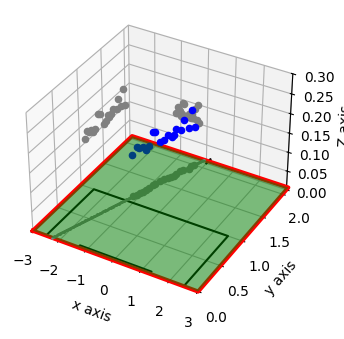

In [25]:
#Trajectory of the ball in the XY plane
plot_data(kick1, xy=hxy)

#### 2.1.5. The influence of the Learning Rate

Let's adopt __Learning Rate__ = 0.000001


In [26]:
#Learning rate influence
htest = LR(x_values, y_values, 0.000001, 20001)

Starting...
i: 1000, J = 3.581101325139311 -> h = [0.37643368 0.94928945]
i: 2000, J = 3.569905553701299 -> h = [0.37832427 0.94786694]
i: 3000, J = 3.558745460399304 -> h = [0.3802119  0.94644677]
i: 4000, J = 3.547620931474671 -> h = [0.38209657 0.94502893]
i: 5000, J = 3.5365318535314856 -> h = [0.38397829 0.94361343]
i: 6000, J = 3.5254781135353896 -> h = [0.38585706 0.94220025]
i: 7000, J = 3.5144595988124347 -> h = [0.38773288 0.94078939]
i: 8000, J = 3.5034761970479344 -> h = [0.38960577 0.93938085]
i: 9000, J = 3.4925277962853216 -> h = [0.39147573 0.93797463]
i: 10000, J = 3.4816142849250147 -> h = [0.39334275 0.93657072]
i: 11000, J = 3.470735551723246 -> h = [0.39520685 0.93516913]
i: 12000, J = 3.459891485790974 -> h = [0.39706803 0.93376983]
i: 13000, J = 3.449081976592715 -> h = [0.3989263  0.93237284]
i: 14000, J = 3.438306913945442 -> h = [0.40078166 0.93097814]
i: 15000, J = 3.4275661880174275 -> h = [0.4026341  0.92958574]
i: 16000, J = 3.416859689327174 -> h = [0.404

The Cost Function (J) is not decreasing as expected. The Learning Rate is __too small!__ <br>
Now let's adopt __Learning Rate__ = 1.253

In [27]:
#Learning rate influence
htest = LR(x_values, y_values, 1.253, 20001)

Starting...
i: 1000, J = 17.304192185953088 -> h = [-0.26620586  3.05824219]
i: 2000, J = 85.18326738146386 -> h = [-3.41602139  5.54825308]
i: 3000, J = 419.3442318706375 -> h = [-10.4046992   11.07298419]
i: 4000, J = 2064.38064208569 -> h = [-25.9108827   23.33102449]
i: 5000, J = 10162.707731457249 -> h = [-60.31534847  50.52864717]
i: 6000, J = 50029.85063431517 -> h = [-136.65052565  110.87358496]
i: 7000, J = 246291.2594038964 -> h = [-306.01979638  244.76438711]
i: 8000, J = 1212463.845838697 -> h = [-681.80918891  541.83565033]
i: 9000, J = 5968821.566036575 -> h = [-1515.5948393   1200.96483634]
i: 10000, J = 29383829.48503083 -> h = [-3365.56326467  2663.41286697]
i: 11000, J = 144653249.5116963 -> h = [-7470.19516054  5908.23085966]
i: 12000, J = 712111489.9381423 -> h = [-16577.37924514  13107.69612966]
i: 13000, J = 3505643847.031545 -> h = [-36784.01507874  29081.56594014]
i: 14000, J = 17257885816.878014 -> h = [-81617.64619002  64523.71437102]
i: 15000, J = 84958608422

Values are not converging. The Learning Rate is __too high!!__

### 2.2. XZ Regression

Now let's repeat the process to the XZ plane.

In [28]:
#Gradient descent for the XZ plane
hxz = LR(x_values, z_values, 0.02, 10001)

Starting...
i: 1000, J = 0.006245518351016021 -> h = [0.346942   0.28934404]
i: 2000, J = 0.0011793830989666766 -> h = [0.21188225 0.11849608]
i: 3000, J = 0.00034284287239622015 -> h = [0.15700012 0.04907125]
i: 4000, J = 0.00020471005204021498 -> h = [0.13469852 0.02086016]
i: 5000, J = 0.00018190101614037709 -> h = [0.12563617 0.00939645]
i: 6000, J = 0.0001781346982056584 -> h = [0.12195364 0.00473813]
i: 7000, J = 0.00017751278893918718 -> h = [0.12045723 0.0028452 ]
i: 8000, J = 0.00017741009682916705 -> h = [0.11984916 0.002076  ]
i: 9000, J = 0.00017739313990308646 -> h = [0.11960206 0.00176343]
i: 10000, J = 0.00017739033990859764 -> h = [0.11950166 0.00163641]
Done!


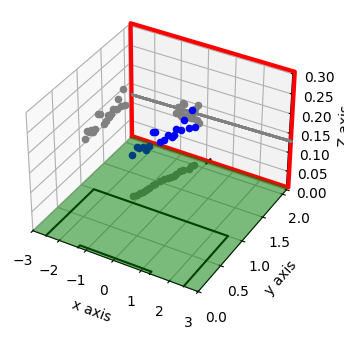

In [29]:
#Trajectory of the ball in the XZ plane
plot_data(kick1, xz=hxz)

### 2.3. YZ Regression

Let's repeat the process to the YZ plane:

In [22]:
#Gradient descent for the YZ plane
hyz = LR(y_values, z_values, 0.02, 10001)

Starting...
i: 1000, J = 0.0009199844173335896 -> h = [-0.0423611   0.10132088]
i: 2000, J = 0.0004896384254613266 -> h = [0.01268702 0.06661573]
i: 3000, J = 0.0003085797488778431 -> h = [0.0483932  0.04410473]
i: 4000, J = 0.00023240326533830773 -> h = [0.07155349 0.0295033 ]
i: 5000, J = 0.00020035367371449225 -> h = [0.08657609 0.02003229]
i: 6000, J = 0.00018686950805698685 -> h = [0.09632028 0.01388906]
i: 7000, J = 0.00018119633987396578 -> h = [0.1026407  0.00990434]
i: 8000, J = 0.00017880947827271214 -> h = [0.10674036 0.00731971]
i: 9000, J = 0.0001778052583871481 -> h = [0.10939954 0.00564322]
i: 10000, J = 0.00017738275480418684 -> h = [0.11112438 0.00455579]
Done!


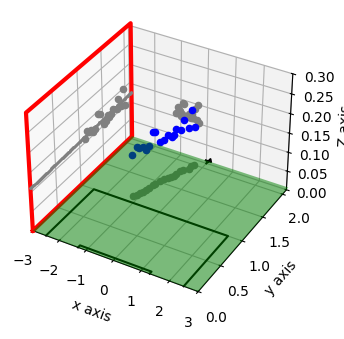

In [33]:
#Trajectory of the ball in the XY plane
plot_data(kick1, yz=hyz)

### 2.4. Final trajectory

Now we can combine the regressions to estimate the trajectory of the ball.

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

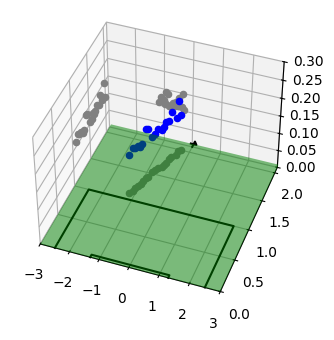

In [34]:
#Ball final trajectory
plot_data(kick1, xy=hxy, xz=hxz, yz=hyz)

### 2.5. Linear Regression with SKLearn

Now let's implement our Linear Regression with SKLearn:

In [35]:
from sklearn.linear_model import LinearRegression

LRSklearn = LinearRegression()
a = np.array(x_values).reshape(-1,1)
b = np.array(y_values).reshape(-1,1)
LRSklearn.fit(a,b)
hxyskl = [LRSklearn.intercept_[0] , LRSklearn.coef_[0,0]]
print('Current coefficients: ', hxyskl)
print('Previous coefficients: ', hxy)

Current coefficients:  [np.float64(2.318241598783087), np.float64(1.0151694350863536)]
Previous coefficients:  [2.31824159 1.01516942]


Note that these are essentially the same coefficients...

Before we can continue, let's free some space in memory...

In [36]:
plt.close('all')

## 3. Polynomial Regression (PR)

### 3.1. Loading data

Let's load data from a new kick...

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


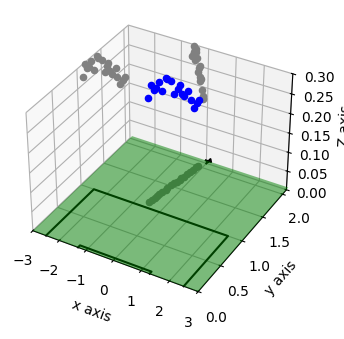

In [38]:
# Loading data...
import pandas as pd
from google.colab import drive
drive.mount('/content/drive/')
path = '/content/drive/My Drive/Colab Notebooks/kick2.dat'

with open(path, "rt") as f:
    kick2 = pd.read_csv(path, names=['X','Y','Z'], skiprows=1, sep=' ')

num_examples, num_dims = kick2.shape
x_values = kick2.iloc[:,0]
y_values = kick2.iloc[:,1]
z_values = kick2.iloc[:,2]
plot_data(kick2)

### 3.2. Creating a Polynomial Regression function

Let's create a PR function with __SKLearn__:

In [39]:
# -------------------------------------
# Create a Polynomial Regression (PR)
# ------------------------------------
def PR(X,Y,degree):
    from sklearn.preprocessing import PolynomialFeatures
    #Step1: prepare the data
    PRSklearn = PolynomialFeatures(degree=degree)
    xt = np.array(X).reshape(-1,1)
    yt = np.array(Y).reshape(-1,1)
    xtpr = PRSklearn.fit_transform(xt)
    #Step2: perform a Linear Regression to find coefficients
    PRSklearn = LinearRegression()
    PRSklearn.fit(xtpr, yt)
    print("R2: " + str(PRSklearn.score(xtpr, yt)))
    #Step3: return the coefficients
    hxyprskl = np.append(PRSklearn.intercept_, PRSklearn.coef_[0,1:])
    print("Coeficients: " + str(np.round(hxyprskl, 3)))
    return(hxyprskl)


We will also need a `plot_curve()` function to plot our curves...

In [40]:
# -------------------------------------
# Plot a regression curve
# ------------------------------------
import matplotlib.pyplot as plt
import numpy as np

def plot_curve(y, coefs, str1, str2, data1, data2):
  z = 0
  eq = ''
  for i in range(0, len(coefs)):
    z = z + coefs[i]*pow(y,i)
    if (i==0):
      eq = eq + str(np.format_float_positional(coefs[i], precision=3))
    elif (i==1):
      eq = str(np.format_float_positional(coefs[i], precision=3)) + "$*" + str1 + "$ + " + eq
    else: # highest degree coefficient
      eq = str(np.format_float_positional(coefs[i], precision=3)) + "$*" + str1 + "^{" + str(i) + "}$ + " + eq

  eq = str2 + " = " + eq
  plt.plot(y, z, 'r-', label=eq)
  plt.title(str1.upper()+str2.upper()+" Regression")
  plt.xlabel(str1)
  plt.ylabel(str2)
  plt.legend(loc='center', fontsize=13)
  plt.grid(True)
  if (str1=="y") and (str2=="z"):
    plt.axis([0, 2.1, 0, 0.3])
  if (str1=="x") and (str2=="y"):
    plt.axis([-3, 3, 0, 2.1])
  if (str1=="y") and (str2=="x"):
    plt.axis([0, 2.1,3, -3 ])
  if (str1=="x") and (str2=="z"):
    plt.axis([-3, 3, 0, 0.3])
  plt.scatter(data1, data2, marker='o', color='b', s=10)
  plt.show()


### 3.3. YZ Polynomial Regression

Let's proceed the YZ regression...<br>
In Polynomial Regression we must select the **curve degree**. We can explore values from 1 onwards... <br>
Let's observe the **R2 score** in each case...

R2: 0.912545950806493
Coeficients: [ 0.075  0.372 -0.165]


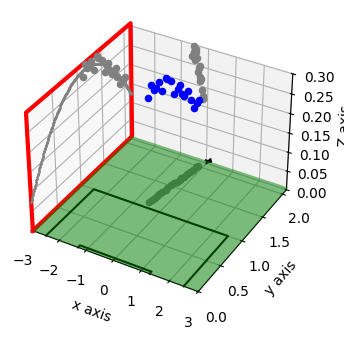

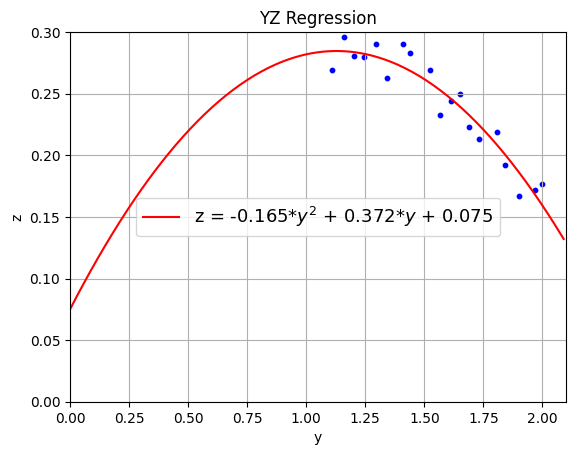

In [41]:
# -------------------------
# YZ Polynomial Regression
# -------------------------
degree = 2

hyzprskl = PR(y_values, z_values, degree)
plot_data(kick2, yz=hyzprskl)
plot_curve(np.arange(0,2.1,0.01),hyzprskl,'y','z',y_values, z_values)

### 3.4. YX Polynomial Regression

Let's proceed the YX regression...

R2: 0.9866824391267555
Coeficients: [-0.991  0.304  0.057]


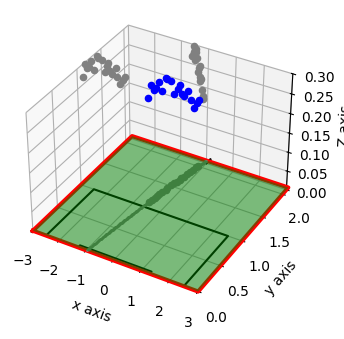

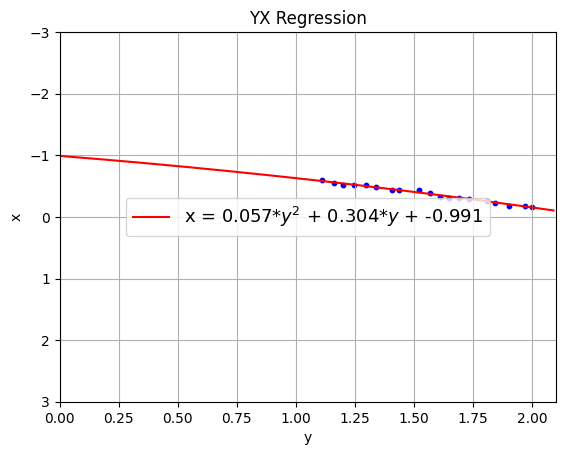

In [42]:
# -------------------------
# YX Polynomial Regression
# -------------------------
degree = 2

hyxprskl = PR(y_values, x_values, degree)
plot_data(kick2, yx=hyxprskl)
plot_curve(np.arange(0,2.1,0.01), hyxprskl,'y','x',y_values, x_values)

### 3.5. XZ Polynomial Regression

Let's proceed the XZ regression...

R2: 0.9170750271944295
Coeficients: [ 0.049 -0.811 -0.701]


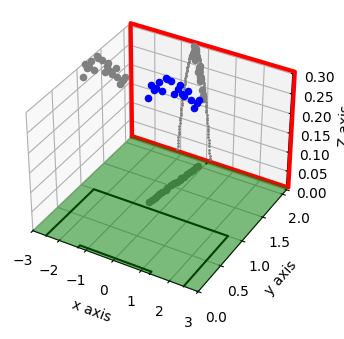

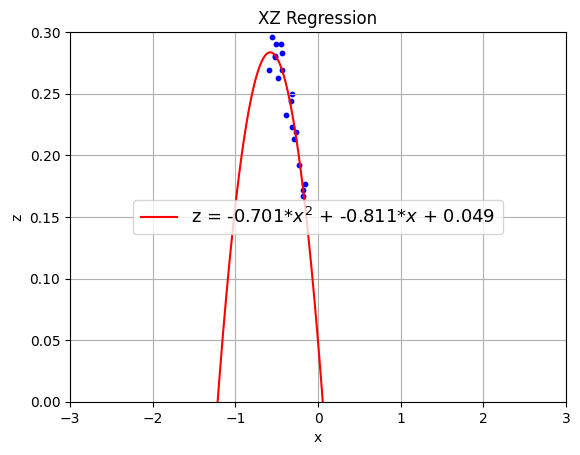

In [43]:
# -------------------------
# XZ Polynomial Regression
# -------------------------
degree = 2

hxzprskl = PR(x_values, z_values, degree)
plot_data(kick2, xz=hxzprskl)
plot_curve(np.arange(-3,3,0.01),hxzprskl,'x','z',x_values, z_values)

### 3.6. Final trajectory

Let's ckeck the final trajectory of the ball...

R2: 0.9866824391267555
Coeficients: [-0.991  0.304  0.057]
R2: 0.9170750271944295
Coeficients: [ 0.049 -0.811 -0.701]


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

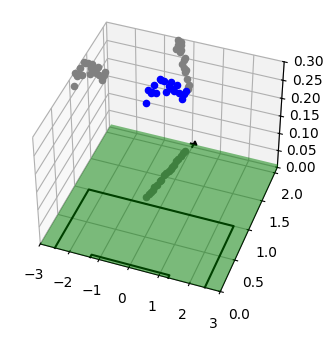

In [44]:
# 3D ball trajectory (main curve ploted using only YX and XZ degrees)
hyxprskl = PR(y_values, x_values, 2)
hxzprskl = PR(x_values, z_values, 2)
plot_data(kick2, yx=hyxprskl, yz=hyzprskl, xz=hxzprskl)

If we generate values in y, we can now estimate the position of the ball along x and z...

R2: 0.9866824391267555
Coeficients: [-0.991  0.304  0.057]
R2: 0.9170750271944295
Coeficients: [ 0.049 -0.811 -0.701]


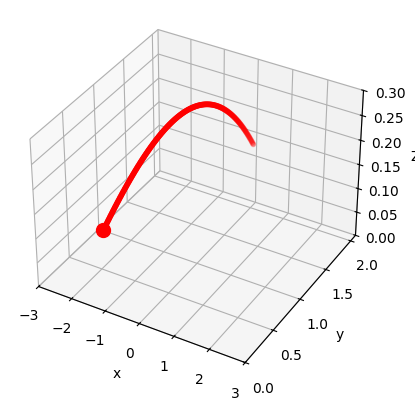

The the kick will hit the goal in the position: x =  -0.987 , y=  0.01 , z=  0.166


In [45]:
# ---------------------------------------
# Estimate the ball position
# ---------------------------------------

# Generating a linear trajectory in y axis of the field...
y = np.arange(2.1,0,-0.01)
# Run polynomial regression for degree=2
hyxprskl = PR(y_values, x_values, 2)
hxzprskl = PR(x_values, z_values, 2)
# Using equations obtained to estimate x and y position...
x = hyxprskl[0] + hyxprskl[1]*y + hyxprskl[2]*y*y # YX plane
z = hxzprskl[0] + hxzprskl[1]*x + hxzprskl[2]*x*x # XZ plane
# Plot ball trajectory
fig = plt.figure()
ax = plt.subplot(projection='3d')
ax.scatter(x, y, z, marker='o', color='r', s=10)
last_pos = len(y)-1
ax.scatter(x[last_pos],y[last_pos],z[last_pos], marker="o", color='r', s=100)
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.xlim(-3,3)
plt.ylim(0,2.1)
plt.xlabel('x')
plt.ylabel('y')
ax.set_zlabel('Z')
ax.set_zlim(0,0.3)
ax.view_init(elev=35, azim=-60, roll=0)
plt.show()

print("The the kick will hit the goal in the position: x = ", np.round(x[last_pos],3), ", y= ", np.round(y[last_pos],3), ", z= ", np.round(z[last_pos],3))

## 4. Regularization (L1/L2)

Example of how to use regularizaton to select polynomial coeficients/degree.

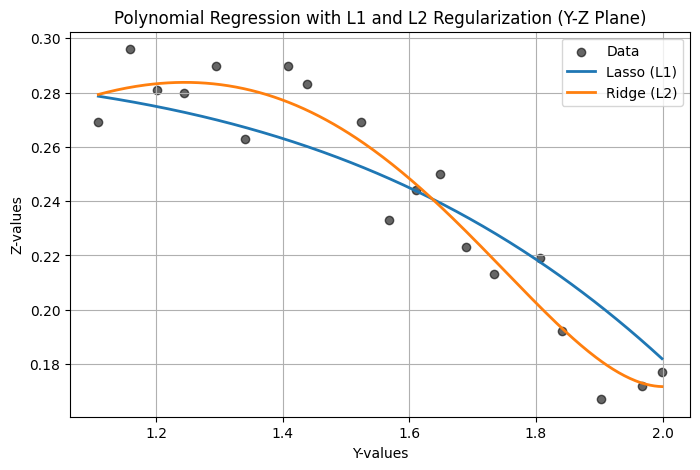

=== Lasso (L1) ===
Selected coefficients: [-0.         -0.         -0.         -0.02973501 -0.         -0.
 -0.         -0.         -0.         -0.        ]

=== Ridge (L2) ===
Coefficients: [ 0.05375355  0.00693387 -0.02413356 -0.0407171  -0.04471002 -0.03826768
 -0.02350248 -0.00228518  0.02384681  0.05370069]

Alpha (Lasso): 0.01
Alpha (Ridge): 0.01


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV, Ridge

# ====================================
# Hyperparameters
# ====================================

DEGREE = 10  # Maximum degree of the polynomial
LASSO_ALPHA = 0.01 # Set to a specific alpha (e.g., 0.1) or None for auto-selection by LassoCV
RIDGE_ALPHA = 0.01 #Alphas for Ridge

# =====================================
# 1. Load data (kick2.dat)
# =====================================

# Escolha do plano (ex: x → y)
# Reshape y_values and z_values to be 2-dimensional for sklearn
X = y_values.values.reshape(-1, 1)
y = z_values.values.reshape(-1, 1)

# =====================================
# 2. Model setup
# =====================================

degree = DEGREE

# User-configurable regularization parameters
lasso_alpha_choice = LASSO_ALPHA
ridge_alphas_range = RIDGE_ALPHA

# Pipeline Lasso (L1)
lasso_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LassoCV(alphas=None if lasso_alpha_choice is None else [lasso_alpha_choice], cv=5, max_iter=10000))
])

# Pipeline Ridge (L2)
ridge_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=RIDGE_ALPHA))
])

# =====================================
# 3. Train models
# =====================================

lasso_pipeline.fit(X, y.ravel()) # .ravel() to convert y to 1D for LassoCV/RidgeCV
ridge_pipeline.fit(X, y.ravel()) # .ravel() to convert y to 1D for LassoCV/RidgeCV

# =====================================
# 4. Predictions (smooth curve)
# =====================================

X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1,1)

y_lasso = lasso_pipeline.predict(X_plot)
y_ridge = ridge_pipeline.predict(X_plot)

# =====================================
# 5. Plot
# =====================================

plt.figure(figsize=(8,5))

# Dados reais
plt.scatter(X, y, color="black", label="Data", alpha=0.6)

# Modelos
plt.plot(X_plot, y_lasso, label="Lasso (L1)", linewidth=2)
plt.plot(X_plot, y_ridge, label="Ridge (L2)", linewidth=2)

plt.xlabel("Y-values")
plt.ylabel("Z-values")
plt.title("Polynomial Regression with L1 and L2 Regularization (Y-Z Plane)")
plt.legend()
plt.grid()

plt.show()

# =====================================
# 6. Coefficient analysis
# =====================================

lasso_coefs = lasso_pipeline.named_steps["model"].coef_
ridge_coefs = ridge_pipeline.named_steps["model"].coef_

print("=== Lasso (L1) ===")
print("Selected coefficients:", lasso_coefs)

print("\n=== Ridge (L2) ===")
print("Coefficients:", ridge_coefs)

print(f"\nAlpha (Lasso): {lasso_pipeline.named_steps['model'].alpha_}")
print(f"Alpha (Ridge): {RIDGE_ALPHA}")

____
<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/0/0a/Logo_Unesp.svg" width="400" style="float: left; margin-right: 5px;" border="0px" />
</center>